# Regrid bottom roughness topog and save water column depth as a topog file.

Repeat for new tidal roughness file from panan with no ice shelves https://github.com/ACCESS-NRI/access-om3-configs/pull/1175 

File: `/g/data/vk83/prerelease/configurations/inputs/access-om3/panan.4km/2026.02.27/bottom_roughness.nc`

In [1]:
#import cosima_cookbook as cc
#from cosima_cookbook import distributed as ccd
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import xarray as xr
import glob,os
import cmocean.cm as cmocean
import xesmf as xe

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client
import cmocean as cm

In [2]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42623,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37269,Total threads: 4
Dashboard: /proxy/39201/status,Memory: 35.88 GiB
Nanny: tcp://127.0.0.1:40815,


In [3]:
tidal_roughness = xr.open_dataset('/g/data/vk83/prerelease/configurations/inputs/access-om3/panan.4km/2026.02.27/bottom_roughness.nc')


In [4]:
tidal_roughness

<xarray.Dataset> Size: 150MB
Dimensions:  (y: 1442, x: 4320)
Coordinates:
    lon      (y, x) float64 50MB ...
    lat      (y, x) float64 50MB ...
Dimensions without coordinates: y, x
Data variables:
    h2       (y, x) float64 50MB ...
Attributes:
    history:    Created by ml0072 (minghangli-uni) on 2026-02-27, using https...
    inputFile:  /g/data/vk83/prerelease/configurations/inputs/access-om3/pana...

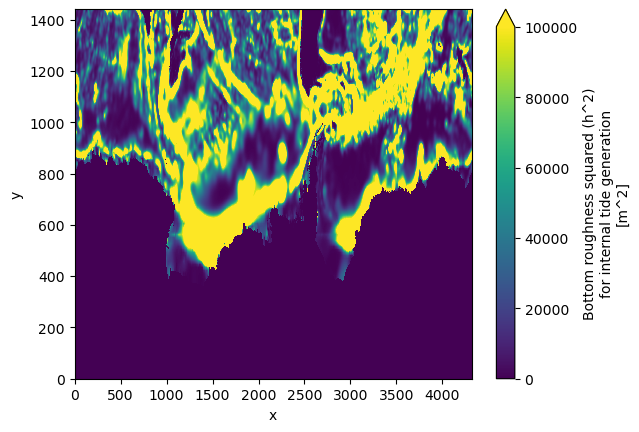

In [7]:
tidal_roughness.h2.plot(vmax = 100000)

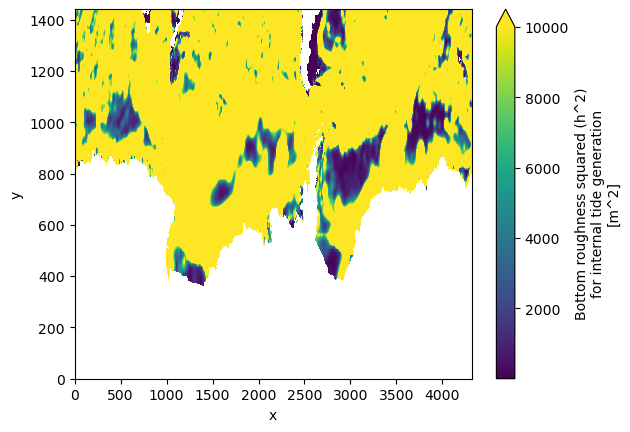

In [8]:
tidal_roughness.h2.where(tidal_roughness.h2>0).plot(vmax = 10000)

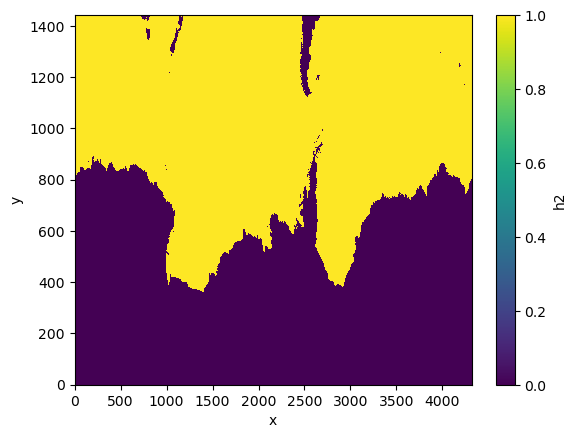

In [11]:
tidal_roughness_smooth_mask = (tidal_roughness.h2.where(tidal_roughness.h2>0)*0+1).fillna(0)
tidal_roughness_smooth_mask.plot()

Create smoothed extrapolated tidal roughness by 1deg filter

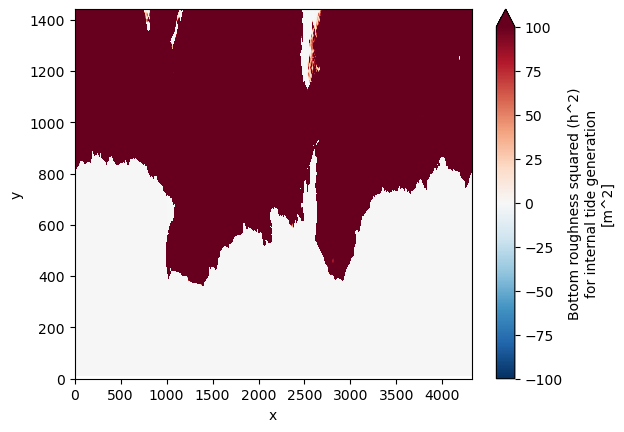

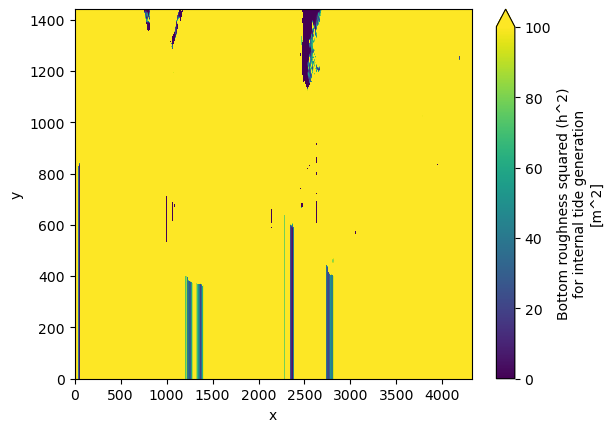

In [12]:
smoothed_tidal_roughness = tidal_roughness.h2.rolling(y = 12).mean()
smoothed_tidal_roughness.plot(vmax = 100)
plt.show()
smoothed_tidal_roughness = smoothed_tidal_roughness.where(smoothed_tidal_roughness>0).bfill('y').bfill('x')
smoothed_tidal_roughness.plot(vmax = 100)
plt.show()


where land or cavities, use extrapolated smoothed tidal roughness, otherise use original

In [13]:
extended_tidal_roughness = tidal_roughness.copy()
extended_tidal_roughness['h2'] = tidal_roughness.h2.where(tidal_roughness.h2>0).fillna(0) + \
                        smoothed_tidal_roughness.where(tidal_roughness.h2==0).where(tidal_roughness.y<1100).fillna(0)


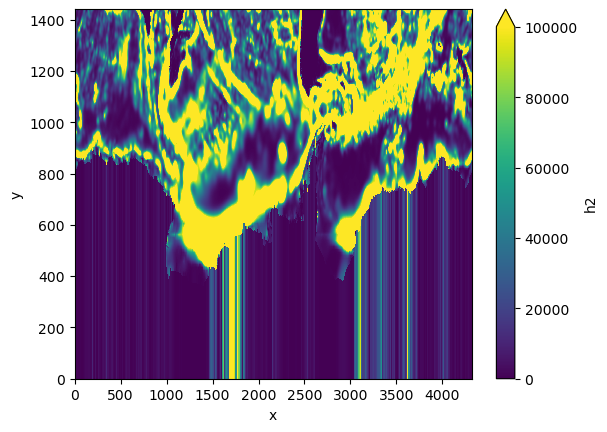

In [14]:
extended_tidal_roughness.h2.plot(vmax = 100000)

Check we only changed stuff in cavities/land:

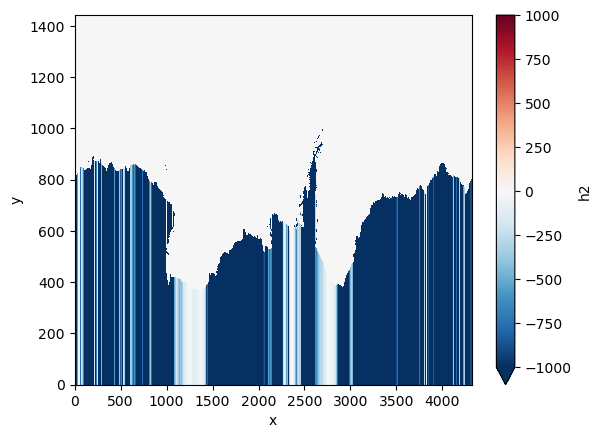

In [15]:
(tidal_roughness.h2 - extended_tidal_roughness.h2).plot(vmax = 1000, vmin = -1000, cmap = 'RdBu_r')

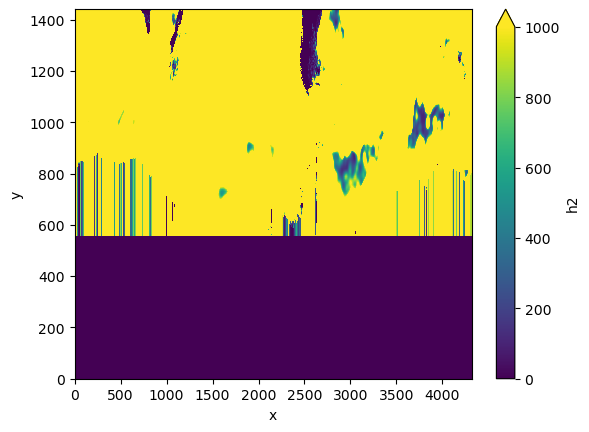

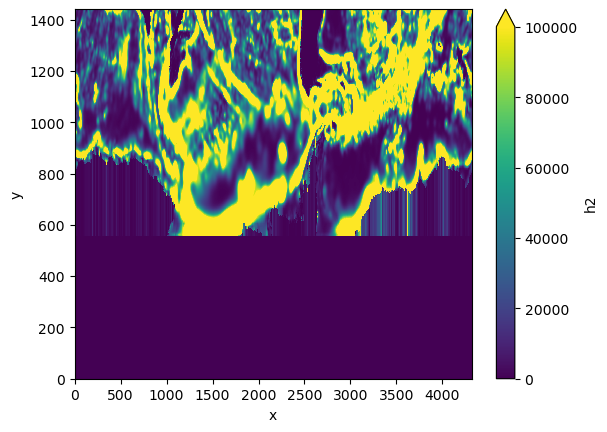

In [16]:
# Now turn to zero below 74.5 S
extended_tidal_roughness['h2'] = extended_tidal_roughness.h2.where(extended_tidal_roughness.lat>-74.5).fillna(0)
extended_tidal_roughness.h2.plot(vmax = 1000)
plt.show()
extended_tidal_roughness.h2.plot(vmax = 100000)
plt.show()


In [17]:
extended_tidal_roughness.attrs['description'] = 'Minghangs file /g/data/vk83/prerelease/configurations/inputs/access-om3/panan.4km/2026.02.27/bottom_roughness.nc but now extended into cavities with smoothed over 1 degree and set to zero for latitudes south of 74.5S - see https://github.com/claireyung/mom6-panAn-iceshelf-tools/generate-draft/tidal_roughness_extrap-2026.ipynb'
extended_tidal_roughness

<xarray.Dataset> Size: 150MB
Dimensions:  (y: 1442, x: 4320)
Coordinates:
    lon      (y, x) float64 50MB ...
    lat      (y, x) float64 50MB -86.49 -86.49 -86.49 ... -37.5 -37.5 -37.5
Dimensions without coordinates: y, x
Data variables:
    h2       (y, x) float64 50MB 0.0 0.0 0.0 ... 1.113e+05 1.121e+05 1.11e+05
Attributes:
    history:      Created by ml0072 (minghangli-uni) on 2026-02-27, using htt...
    inputFile:    /g/data/vk83/prerelease/configurations/inputs/access-om3/pa...
    description:  Minghangs file /g/data/vk83/prerelease/configurations/input...

In [19]:
extended_tidal_roughness.to_netcdf('/g/data/x77/cy8964/mom6/input/input-8km/rerun2026/bottom_roughness_extended_into_cavity_74Sedit.nc')